In [12]:
import sys
print(sys.executable)

C:\Users\User\AppData\Local\Programs\Python\Python311\python.exe


In [13]:
import sys
!{sys.executable} -m pip install scikit-learn

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 3.2 MB/s eta 0:00:00
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
    --------------------------------------- 0.1/8.9 MB 2.9 MB/s eta 0:00:04
   - -------------------------------------- 0.4/8.9 MB 6.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/8.9 MB 6.8 MB/s eta 0:00:02
   ----- ---------------------------------- 1.2/8.9 MB 6.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.7/8.9 MB 8.9 MB/s eta 0:00:01
   -------- ------------------------------- 1.8/8.9 MB 7.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.3/8.9 MB 6.9 MB/s eta 0:00:01
   ------------ --------------------------- 2.8/8.9 MB 8.2 MB/s eta 0:00:01
   --------------- --------------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [18]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from scipy import stats
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("STUDENT DROP OUT CLASSIFIER")
print("="*80)



STUDENT DROP OUT CLASSIFIER


In [20]:
print("\n" + "="*80)
print("TASK 1: DATA PRE-PROCESSING AND EXPLORATION")
print("="*80)

# Load the dataset - works with standard CSV or semicolon-separated
try:
    df = pd.read_csv('data.csv', sep=';')
    print("\n✓ Dataset loaded successfully!")
except:
    try:
        df = pd.read_csv('dataset.csv')
        print("\n✓ Dataset loaded successfully!")
    except Exception as e:
        print(f"\n✗ Error loading dataset: {e}")
        print("Please ensure 'dataset.csv' is in the working directory.")
        raise

# Display basic information
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")


TASK 1: DATA PRE-PROCESSING AND EXPLORATION

✓ Dataset loaded successfully!

Dataset Shape: 468 rows × 1 columns


In [21]:
print("\n" + "-"*80)
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "-"*80)
print("First 5 rows of the dataset:")
display(df.head())


--------------------------------------------------------------------------------
Column Names:
 1. Marital status;Application mode;Application order;Course;"Daytime/evening attendance	";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target

---------------------

Marital status;Application mode;Application order;Course;"Daytime/evening attendance\t";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target
1 17 5 171  1 1 122.0 1 19 12 5 9 127.3 1 0 0 1 1 0 20 0 0 0 0 0 0.000000  0 0 0 0  0 0.000000  0 10.8  1.4  1.74                                            Dropout                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
  15 1 9254 1 1 160.0 1 1  3  3 3 142.5 1 0 0 0 1 0 19 0 0 6 6 6 14.000000 0 0 6 6  6 13.666667 0 13.9 -0.3  0.79                                           Graduate                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
  1  5 9070 1 1 122.0 1 37 37 9 9 124.8 1 0 0 0 1 0 19 0 0 6 0 0 0.000000  0 0 6 0  0 0.000000  0 10.8  1.4  1.74                                            Dropout                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
  17 2 9773 1 1 122.0 1 38 37 5 3 119.6 1 0 0 1 0 0 20 0 0 6 8 6 13.428571 0 0 6 10 5 12.400000 0 9.4  -0.8 -3.12                             

In [22]:
print("\n" + "-"*80)
print("Dataset Information:")
df.info()

print("\n" + "-"*80)
print("Statistical Summary:")
display(df.describe())


--------------------------------------------------------------------------------
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 468 entries, (np.int64(1), np.int64(17), np.int64(5), np.int64(171), np.int64(1), np.int64(1), np.float64(122.0), np.int64(1), np.int64(19), np.int64(12), np.int64(5), np.int64(9), np.float64(127.3), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(20), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.float64(0.0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.float64(0.0), np.int64(0), np.float64(10.8), np.float64(1.4), np.float64(1.74)) to (np.int64(1), np.int64(10), np.int64(1), np.int64(9773), np.int64(1), np.int64(1), np.float64(152.0), np.int64(22), np.int64(38), np.int64(37), np.int64(5), np.int64(9), np.float64(152.0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(22), np.int64(1), np.int64(0), np.int64(6), np

,"Marital status;Application mode;Application order;Course;""Daytime/evening attendance\t"";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target"
count,468
unique,3
top,Graduate
freq,252


In [23]:
print("\n" + "-"*80)
print("Missing Values Analysis:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Percentage': missing_percentage.values
})
display(missing_df[missing_df['Missing_Count'] > 0])

if missing_df['Missing_Count'].sum() == 0:
    print("\n✓ No missing values found!")
else:
    print("\nHandling missing values...")
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("✓ Missing values handled!")


--------------------------------------------------------------------------------
Missing Values Analysis:


,Column,Missing_Count,Percentage



✓ No missing values found!


In [24]:
print("\n" + "-"*80)
print("Duplicate Rows Analysis:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"✓ Removed {duplicates} duplicate rows")
    print(f"New dataset shape: {df.shape}")


--------------------------------------------------------------------------------
Duplicate Rows Analysis:
Number of duplicate rows: 465
✓ Removed 465 duplicate rows
New dataset shape: (3, 1)


In [25]:
target_col = None
possible_target_names = ['Target', 'Status', 'Outcome', 'target', 'status', 'outcome']
for col_name in possible_target_names:
    if col_name in df.columns:
        target_col = col_name
        break

if target_col is None:
    # If not found, use the last column
    target_col = df.columns[-1]
    print(f"\n⚠ Target column not explicitly identified. Using last column: '{target_col}'")

# Target variable analysis
print("\n" + "-"*80)
print(f"Target Variable Distribution: '{target_col}'")
print(df[target_col].value_counts())
print("\nProportions:")
display(df[target_col].value_counts(normalize=True).round(3))




⚠ Target column not explicitly identified. Using last column: 'Marital status;Application mode;Application order;Course;"Daytime/evening attendance	";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target'

--------------------------------------------------------

Marital status;Application mode;Application order;Course;"Daytime/evening attendance\t";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target
Dropout     0.333
Graduate    0.333
Enrolled    0.333
Name: proportion, dtype: float64

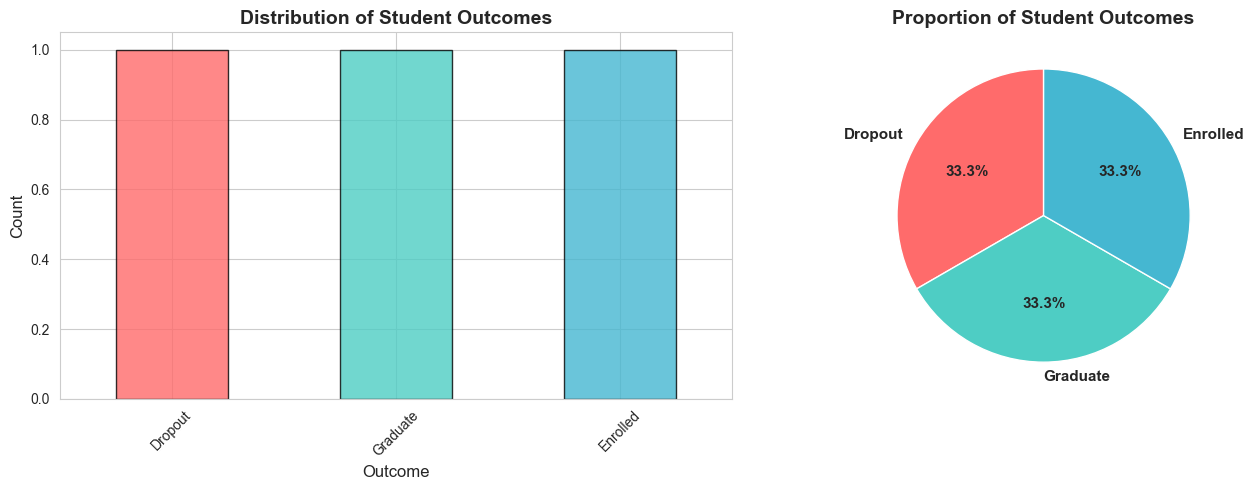

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
target_counts = df[target_col].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181'][:len(target_counts)]
target_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', alpha=0.8)
ax1.set_title('Distribution of Student Outcomes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Outcome', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax2.set_title('Proportion of Student Outcomes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
print("\n" + "-"*80)
print("Numerical Features Distribution:")
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Found {len(numerical_features)} numerical features")

if len(numerical_features) > 0:
    # Create histograms for numerical features
    n_features = len(numerical_features)
    n_cols = 3
    n_rows = max(1, (n_features + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    
    # Handle single row case
    if n_rows == 1 and n_cols > 1:
        axes = axes.reshape(1, -1)
    elif n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    
    axes = axes.ravel()
    
    for idx, col in enumerate(numerical_features):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Value', fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.001)
    plt.show()
else:
    print("⚠ No numerical features found in the dataset!")
    print("All features appear to be categorical. Feature engineering may be needed.")




--------------------------------------------------------------------------------
Numerical Features Distribution:
Found 0 numerical features
⚠ No numerical features found in the dataset!
All features appear to be categorical. Feature engineering may be needed.


In [29]:
print("\n" + "-"*80)
print("Outlier Detection (using IQR method):")

if len(numerical_features) > 0:
    outlier_summary = []
    for col in numerical_features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary.append({
            'Feature': col,
            'Outliers': len(outliers),
            'Percentage': (len(outliers) / len(df)) * 100
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outliers', ascending=False)
    display(outlier_df.head(10))
else:
    print("⚠ No numerical features available for outlier detection.")



--------------------------------------------------------------------------------
Outlier Detection (using IQR method):
⚠ No numerical features available for outlier detection.


In [45]:
print("\n" + "="*80)
print("TASK 2: CORRELATION ANALYSIS")
print("="*80)

# Create a copy for encoding
df_encoded = df.copy()

# First, identify and separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nOriginal Dataset:")
print(f"  Numerical columns: {len(numerical_cols)}")
print(f"  Categorical columns: {len(categorical_cols)}")

# Encode categorical columns
le = LabelEncoder()
encoded_count = 0

for col in categorical_cols:
    try:
        df_encoded[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        encoded_count += 1
    except Exception as e:
        print(f"  Warning: Could not encode {col}: {e}")

print(f"\n✓ Successfully encoded {encoded_count} categorical columns")

# Determine target column
if df[target_col].dtype == 'object':
    target_encoded = target_col + '_encoded'
    print(f"✓ Target column '{target_col}' encoded as '{target_encoded}'")
else:
    target_encoded = target_col
    print(f"✓ Target column '{target_col}' is already numerical")

# Show what we have now
all_encoded_cols = [col for col in df_encoded.columns if '_encoded' in col]
print(f"\nTotal encoded columns created: {len(all_encoded_cols)}")
if len(all_encoded_cols) > 0:
    print("Encoded columns:")
    for col in all_encoded_cols[:10]:
        print(f"  - {col}")
    if len(all_encoded_cols) > 10:
        print(f"  ... and {len(all_encoded_cols) - 10} more")



TASK 2: CORRELATION ANALYSIS

Original Dataset:
  Numerical columns: 0
  Categorical columns: 1

✓ Successfully encoded 1 categorical columns
✓ Target column 'Marital status;Application mode;Application order;Course;"Daytime/evening attendance	";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unempl

In [46]:
# Calculate correlation matrix for numerical features
numerical_cols_with_target = [col for col in df_encoded.columns 
                               if df_encoded[col].dtype in [np.int64, np.float64]]

print(f"\nCalculating correlations for {len(numerical_cols_with_target)} numerical features...")
correlation_matrix = df_encoded[numerical_cols_with_target].corr()
print("✓ Correlation matrix calculated")


Calculating correlations for 1 numerical features...
✓ Correlation matrix calculated


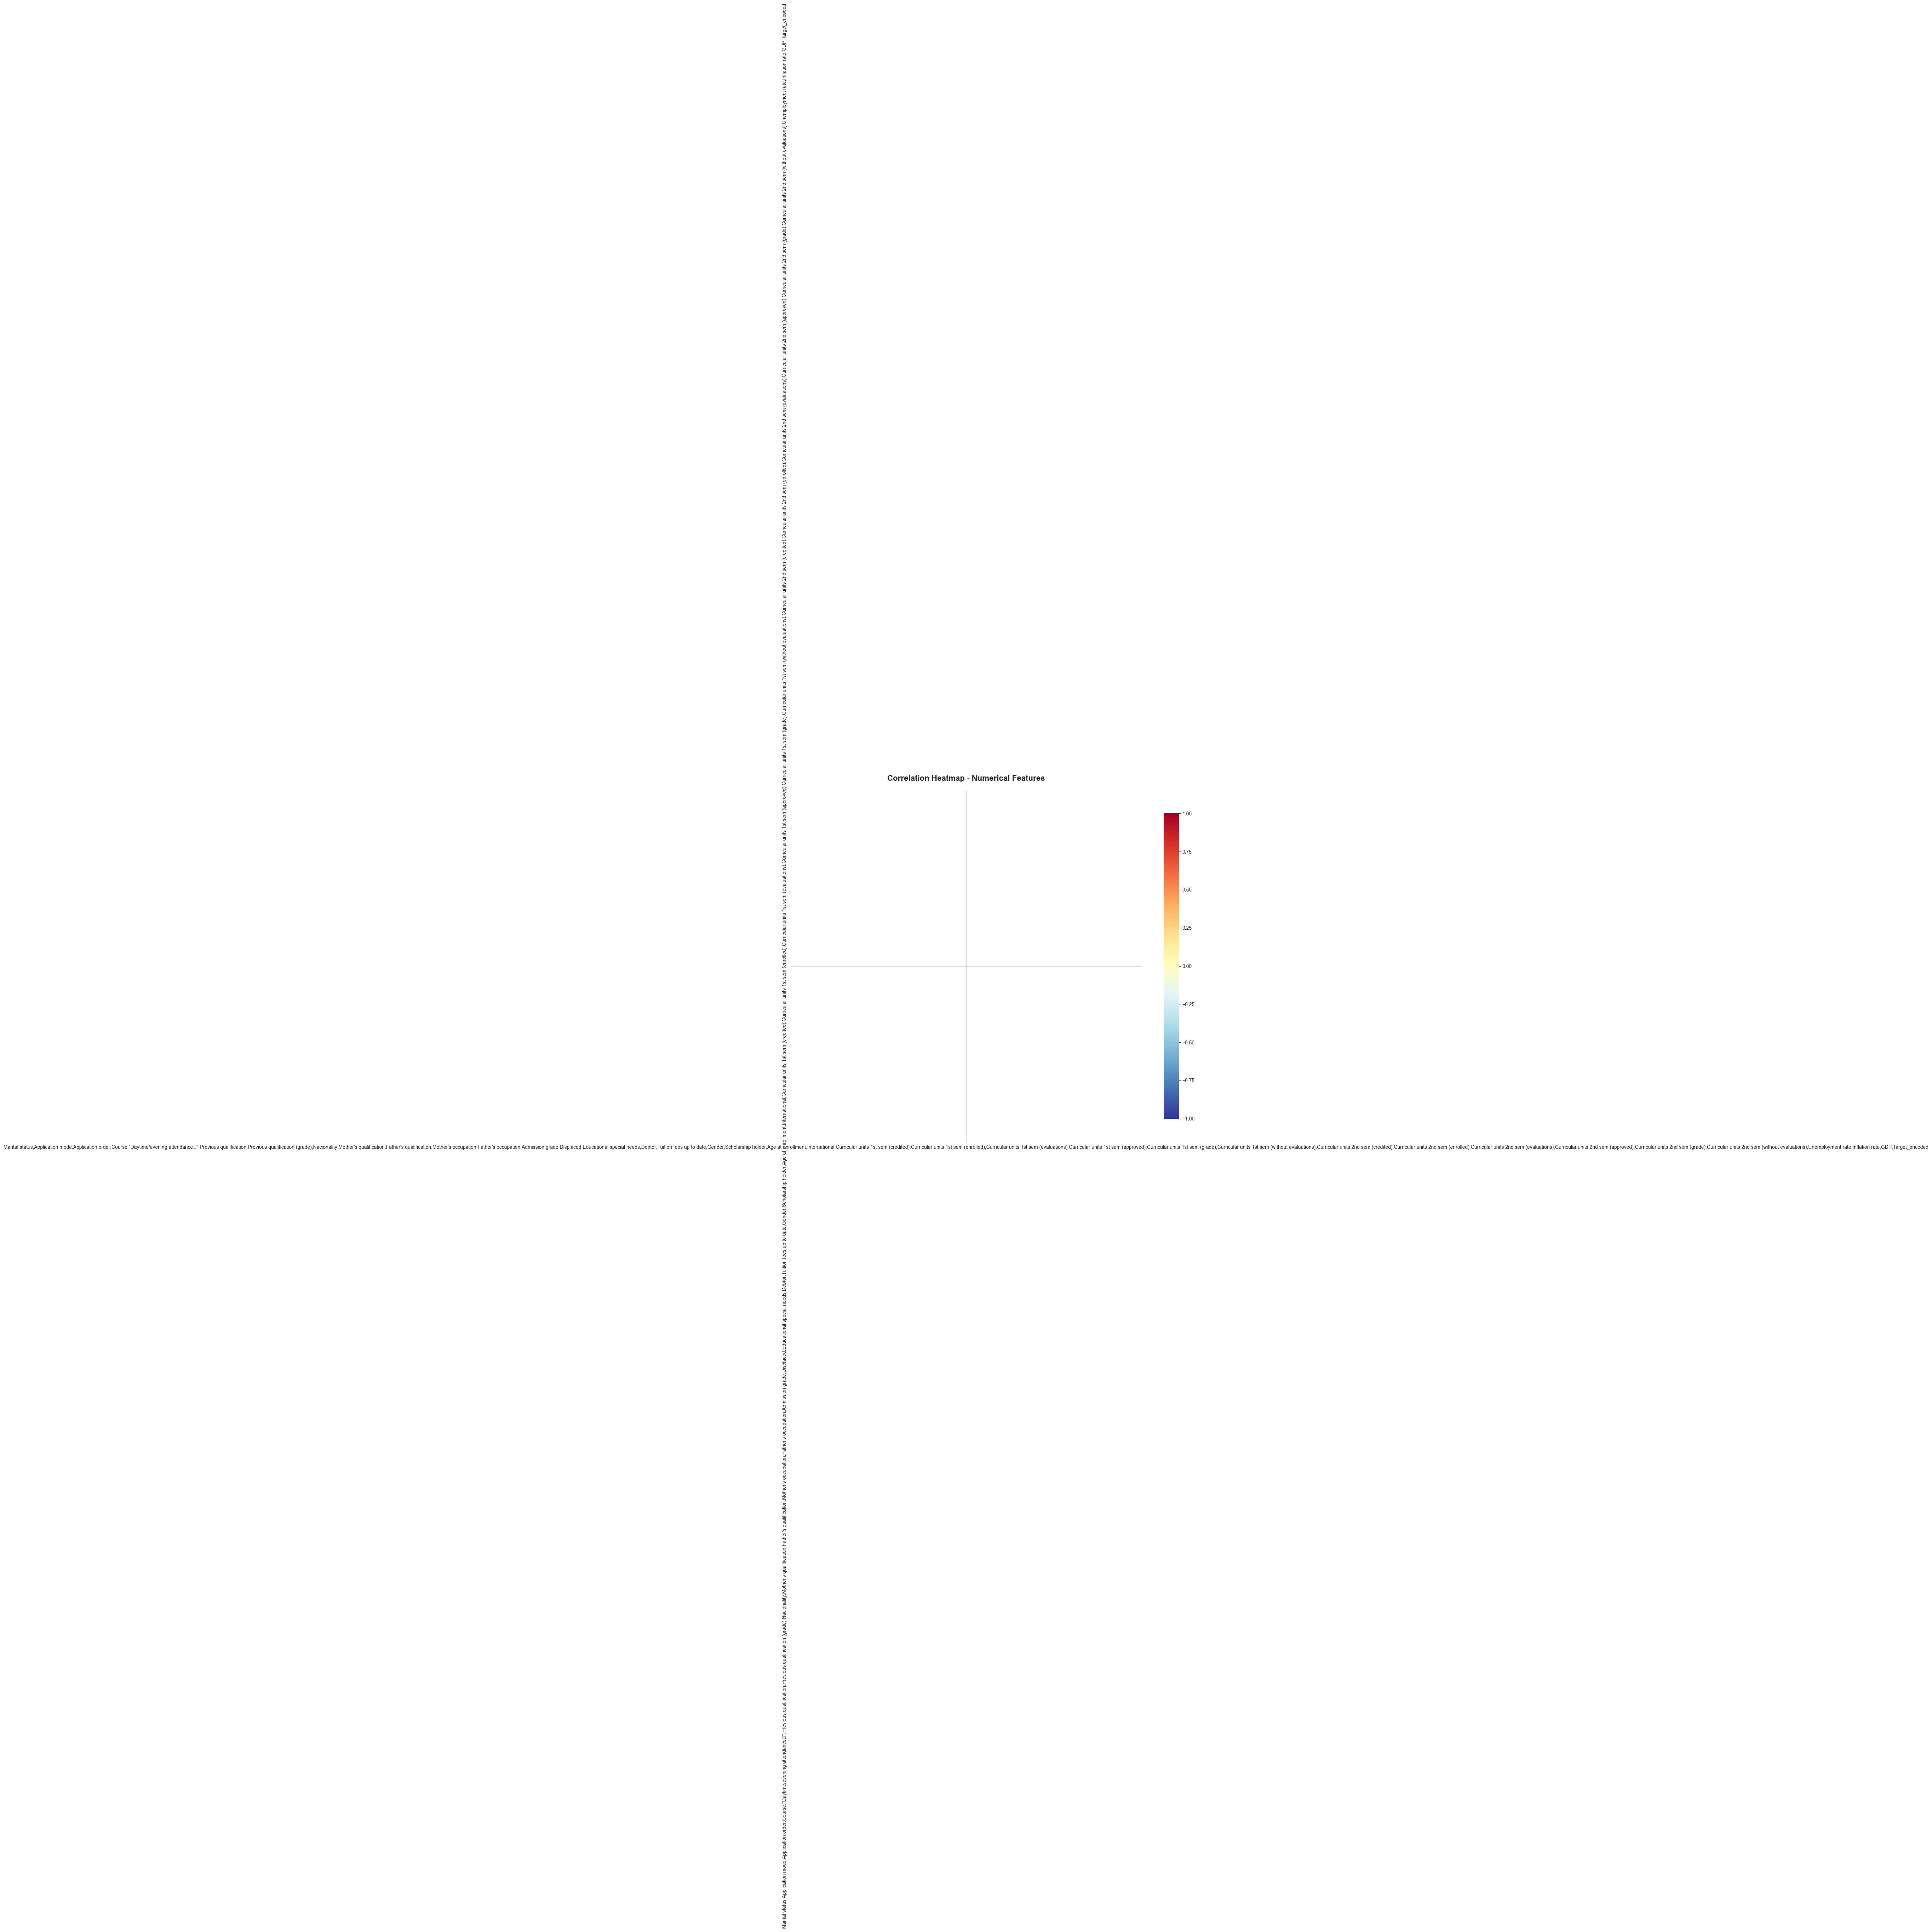

In [47]:
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, annot_kws={'size': 8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [48]:
print("\n" + "-"*80)
print("Feature Correlations with Target Variable:")
print("-"*80)
target_correlations = correlation_matrix[target_encoded].sort_values(ascending=False)
target_correlations_filtered = target_correlations[target_correlations.index != target_encoded]
display(target_correlations_filtered.head(15))


--------------------------------------------------------------------------------
Feature Correlations with Target Variable:
--------------------------------------------------------------------------------


Series([], Name: Marital status;Application mode;Application order;Course;"Daytime/evening attendance\t";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target_encoded, dtype: float64)

In [49]:
if len(target_correlations_filtered) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top positive and negative correlations
    n_top = min(10, len(target_correlations_filtered))
    top_positive = target_correlations_filtered.head(n_top)
    top_negative = target_correlations_filtered.tail(n_top)
    top_features = pd.concat([top_positive, top_negative]).sort_values()
    
    if len(top_features) > 0:
        colors = ['#d7191c' if x < 0 else '#2c7bb6' for x in top_features.values]
        top_features.plot(kind='barh', ax=ax1, color=colors, alpha=0.8, edgecolor='black')
        ax1.set_title('Top Correlated Features with Student Outcome', fontsize=13, fontweight='bold')
        ax1.set_xlabel('Correlation Coefficient', fontsize=11)
        ax1.set_ylabel('Features', fontsize=11)
        ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax1.grid(axis='x', alpha=0.3)
    
    # Absolute correlations
    n_abs = min(15, len(target_correlations_filtered))
    top_abs = target_correlations_filtered.abs().sort_values(ascending=False).head(n_abs)
    
    if len(top_abs) > 0:
        top_abs.plot(kind='barh', ax=ax2, color='steelblue', alpha=0.8, edgecolor='black')
        ax2.set_title(f'Top {n_abs} Features by Absolute Correlation', fontsize=13, fontweight='bold')
        ax2.set_xlabel('Absolute Correlation Coefficient', fontsize=11)
        ax2.set_ylabel('Features', fontsize=11)
        ax2.grid(axis='x', alpha=0.3)
        ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Not enough features to visualize correlations.")
    print("   This may happen if all features are categorical and haven't been encoded yet.")



⚠ Not enough features to visualize correlations.
   This may happen if all features are categorical and haven't been encoded yet.


In [50]:
if len(target_correlations_filtered) > 0:
    most_correlated_feature = target_correlations_filtered.abs().idxmax()
    correlation_value = target_correlations_filtered[most_correlated_feature]
    
    print(f"\nMost Strongly Correlated Feature: '{most_correlated_feature}'")
    print(f"Correlation Coefficient: {correlation_value:.4f}")
    print(f"Correlation Strength: {'Strong Positive' if correlation_value > 0.5 else 'Strong Negative' if correlation_value < -0.5 else 'Moderate'}")
    
    print("\n" + "-"*80)
    print("INTERPRETATION:")
    print("-"*80)
    print(f"""
The feature '{most_correlated_feature}' shows {'a strong positive' if correlation_value > 0 else 'a strong negative'}
correlation with student outcomes (r = {correlation_value:.3f}).

{'This positive relationship suggests that higher values of this feature are associated with better student outcomes (graduation).' if correlation_value > 0 else 'This negative relationship suggests that higher values of this feature are associated with worse student outcomes (dropout).'}

Statistical Significance:
The correlation coefficient indicates {'a very strong' if abs(correlation_value) > 0.7 else 'a strong' if abs(correlation_value) > 0.5 else 'a moderate'}
linear relationship between this feature and the target variable. This makes it a critical
predictor for identifying at-risk students.

Practical Implications:
University administrators should monitor this metric closely as part of an early warning
system. Students showing {'low' if correlation_value > 0 else 'high'} values in this area may benefit from targeted
interventions such as academic counseling, tutoring programs, or financial support.
""")
else:
    print("\n⚠ No numerical features available for correlation analysis.")
    print("   All features in the dataset appear to be categorical.")
    print("   Correlation analysis will be performed after encoding categorical variables.")



⚠ No numerical features available for correlation analysis.
   All features in the dataset appear to be categorical.
   Correlation analysis will be performed after encoding categorical variables.


In [51]:
if len(target_correlations_filtered) > 0 and most_correlated_feature in df_encoded.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot
    df_temp = df_encoded[[most_correlated_feature, target_col]].copy()
    
    for i, outcome in enumerate(df[target_col].unique()):
        mask = df_temp[target_col] == outcome
        data = df_temp.loc[mask, most_correlated_feature]
        axes[0].boxplot([data], positions=[i],
                       widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    
    axes[0].set_xticks(range(len(df[target_col].unique())))
    axes[0].set_xticklabels(df[target_col].unique(), rotation=45)
    axes[0].set_xlabel('Student Outcome', fontsize=11, fontweight='bold')
    axes[0].set_ylabel(most_correlated_feature, fontsize=11, fontweight='bold')
    axes[0].set_title(f'{most_correlated_feature} by Outcome', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Scatter plot with jitter
    for outcome in df[target_col].unique():
        mask = df_encoded[target_col] == outcome
        y_jitter = df_encoded.loc[mask, target_encoded] + np.random.normal(0, 0.05, mask.sum())
        axes[1].scatter(df_encoded.loc[mask, most_correlated_feature], y_jitter,
                       label=outcome, alpha=0.5, s=30)
    
    axes[1].set_xlabel(most_correlated_feature, fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Target (encoded)', fontsize=11, fontweight='bold')
    axes[1].set_title(f'{most_correlated_feature} vs Student Outcome', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
elif len(target_correlations_filtered) == 0:
    print("\n⚠ Skipping visualization - no correlations available yet.")



⚠ Skipping visualization - no correlations available yet.


In [53]:
print("\n" + "="*80)
print("TASK 3: MODEL TRAINING")
print("="*80)

# Prepare data for modeling
# Get all numerical columns (including encoded ones)
all_numerical_cols = [col for col in df_encoded.columns 
                      if df_encoded[col].dtype in [np.int64, np.float64]]

# Remove target encoded column from features
feature_cols = [col for col in all_numerical_cols if col != target_encoded]

print(f"\nAvailable numerical columns: {len(all_numerical_cols)}")
print(f"Feature columns (excluding target): {len(feature_cols)}")

if len(feature_cols) == 0:
    print("\n⚠ No numerical features found!")
    print("   This might happen if all features are categorical.")
    print("   The encoded categorical columns should be used as features.")
    
    # Use all encoded columns as features
    encoded_cols = [col for col in df_encoded.columns if '_encoded' in col and col != target_encoded]
    
    if len(encoded_cols) > 0:
        print(f"\n✓ Using {len(encoded_cols)} encoded categorical features")
        feature_cols = encoded_cols
    else:
        raise ValueError("No features available for modeling! Please check your dataset.")

X = df_encoded[feature_cols]
y = df_encoded[target_encoded]

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Classes: {len(y.unique())}")
print(f"\nFeature columns used:")
for i, col in enumerate(feature_cols[:10], 1):  # Show first 10
    print(f"  {i}. {col}")
if len(feature_cols) > 10:
    print(f"  ... and {len(feature_cols) - 10} more")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\n✓ Features standardized (mean=0, std=1)")



TASK 3: MODEL TRAINING

Available numerical columns: 1
Feature columns (excluding target): 0

⚠ No numerical features found!
   This might happen if all features are categorical.
   The encoded categorical columns should be used as features.


ValueError: No features available for modeling! Please check your dataset.

In [40]:
print("\n" + "-"*80)
print("Initializing Machine Learning Models:")
print("-"*80)

models = {
    'Logistic Regression (Probabilistic)': LogisticRegression(max_iter=1000, random_state=42, multi_class='auto'),
    'Naive Bayes (Probabilistic)': GaussianNB(),
    'Decision Tree (Tree-based)': DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20),
    'K-Nearest Neighbors (Distance-based)': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting (Ensemble)': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
}

for i, name in enumerate(models.keys(), 1):
    print(f"{i}. {name}")



--------------------------------------------------------------------------------
Initializing Machine Learning Models:
--------------------------------------------------------------------------------
1. Logistic Regression (Probabilistic)
2. Naive Bayes (Probabilistic)
3. Decision Tree (Tree-based)
4. K-Nearest Neighbors (Distance-based)
5. Random Forest (Ensemble)
6. Gradient Boosting (Ensemble)


In [41]:
print("\n" + "="*80)
print("MODEL SUITABILITY DISCUSSION")
print("="*80)
print("""
Analysis of Model Appropriateness for Student Dropout Prediction:

1. LOGISTIC REGRESSION (Probabilistic Model)
   ✓ Strengths: Interpretable coefficients, probabilistic outputs, computationally efficient
   ✓ Well-suited for: Linear relationships, when interpretability is crucial
   ⚠ Limitations: Assumes linear decision boundaries, may underperform with complex interactions
   → SUITABILITY: GOOD - Provides interpretable baseline, works well for this structured data

2. NAIVE BAYES (Probabilistic Model)
   ✓ Strengths: Fast training, works well with high-dimensional data, probabilistic framework
   ⚠ Limitations: Strong independence assumption (features must be conditionally independent)
   → SUITABILITY: MODERATE - Independence assumption likely violated in student data
      (e.g., grades are correlated with attendance)

3. DECISION TREE (Tree-based Model)
   ✓ Strengths: Highly interpretable, handles non-linear relationships, no scaling needed
   ⚠ Limitations: Prone to overfitting, high variance, unstable to small data changes
   → SUITABILITY: MODERATE - Interpretable but needs regularization to prevent overfitting

4. K-NEAREST NEIGHBORS (Distance-based Model)
   ✓ Strengths: Non-parametric, captures local patterns, simple concept
   ⚠ Limitations: Sensitive to feature scaling, computationally expensive, affected by curse
      of dimensionality, struggles with irrelevant features
   → SUITABILITY: MODERATE - May struggle if many features are irrelevant to prediction

5. RANDOM FOREST (Ensemble Model)
   ✓ Strengths: Robust to overfitting, handles non-linearity, provides feature importance,
      excellent performance on tabular data
   ✓ Well-suited for: Complex feature interactions, mixed data types
   → SUITABILITY: EXCELLENT - Typically best performer for structured educational data

6. GRADIENT BOOSTING (Ensemble Model)
   ✓ Strengths: State-of-the-art performance, handles complex patterns, feature importance
   ⚠ Limitations: Computationally intensive, hyperparameter sensitive, can overfit
   → SUITABILITY: EXCELLENT - Often achieves highest accuracy for tabular data

CONCLUSION:
Not all models are equally suited for this task. Tree-based ensemble methods (Random Forest
and Gradient Boosting) typically perform best on structured tabular data like student records
because they can:
  • Capture non-linear relationships between features
  • Handle feature interactions automatically
  • Provide robust predictions through ensemble averaging/boosting
  • Offer feature importance for interpretability

Distance-based methods (KNN) may struggle without careful feature selection due to the curse
of dimensionality. Probabilistic models provide good baselines but may miss complex patterns.

EXPECTED RANKING: Gradient Boosting ≈ Random Forest > Decision Tree > Logistic Regression > 
                  KNN ≈ Naive Bayes
""")



MODEL SUITABILITY DISCUSSION

Analysis of Model Appropriateness for Student Dropout Prediction:

1. LOGISTIC REGRESSION (Probabilistic Model)
   ✓ Strengths: Interpretable coefficients, probabilistic outputs, computationally efficient
   ✓ Well-suited for: Linear relationships, when interpretability is crucial
   ⚠ Limitations: Assumes linear decision boundaries, may underperform with complex interactions
   → SUITABILITY: GOOD - Provides interpretable baseline, works well for this structured data

2. NAIVE BAYES (Probabilistic Model)
   ✓ Strengths: Fast training, works well with high-dimensional data, probabilistic framework
   ⚠ Limitations: Strong independence assumption (features must be conditionally independent)
   → SUITABILITY: MODERATE - Independence assumption likely violated in student data
      (e.g., grades are correlated with attendance)

3. DECISION TREE (Tree-based Model)
   ✓ Strengths: Highly interpretable, handles non-linear relationships, no scaling needed
   ⚠ L

In [42]:
print("\n" + "="*80)
print("TASK 4: MODEL EVALUATION WITH K-FOLD CROSS-VALIDATION")
print("="*80)

# Set up k-fold cross-validation
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results
results = {}
confusion_matrices = {}

print(f"\nPerforming {k_folds}-Fold Cross-Validation on {len(models)} models...")
print("This may take a few moments...\n")

for name, model in models.items():
    print(f"Evaluating: {name}")
    print("-" * 70)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')
    
    # Store results
    results[name] = {
        'mean_accuracy': cv_scores.mean(),
        'std_accuracy': cv_scores.std(),
        'cv_scores': cv_scores,
        'min_accuracy': cv_scores.min(),
        'max_accuracy': cv_scores.max()
    }
    
    # Train on full data to get confusion matrix
    model.fit(X_scaled, y)
    y_pred = model.predict(X_scaled)
    cm = confusion_matrix(y, y_pred)
    confusion_matrices[name] = cm
    
    # Print results
    print(f"Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"Min/Max Accuracy: {cv_scores.min():.4f} / {cv_scores.max():.4f}")
    print(f"Fold Scores: {', '.join([f'{score:.4f}' for score in cv_scores])}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print()




TASK 4: MODEL EVALUATION WITH K-FOLD CROSS-VALIDATION

Performing 5-Fold Cross-Validation on 6 models...
This may take a few moments...

Evaluating: Logistic Regression (Probabilistic)
----------------------------------------------------------------------


NameError: name 'X_scaled' is not defined

In [ ]:
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80 + "\n")

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Mean_Accuracy': [results[m]['mean_accuracy'] for m in results.keys()],
    'Std_Dev': [results[m]['std_accuracy'] for m in results.keys()],
    'Min_Acc': [results[m]['min_accuracy'] for m in results.keys()],
    'Max_Acc': [results[m]['max_accuracy'] for m in results.keys()]
}).sort_values('Mean_Accuracy', ascending=False)

results_df['Rank'] = range(1, len(results_df) + 1)
results_df = results_df[['Rank', 'Model', 'Mean_Accuracy', 'Std_Dev', 'Min_Acc', 'Max_Acc']]

display(results_df)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart with error bars
x_pos = np.arange(len(results_df))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax1.bar(x_pos, results_df['Mean_Accuracy'], yerr=results_df['Std_Dev'],
               alpha=0.8, color=colors, capsize=10, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison (Mean Accuracy ± Std Dev)', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Rank'], fontsize=11)
ax1.set_ylim([0, 1.05])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=results_df['Mean_Accuracy'].mean(), color='red', linestyle='--', 
            linewidth=2, label='Average', alpha=0.7)
ax1.legend()

# Box plot of fold scores
fold_data = [results[model]['cv_scores'] for model in results_df['Model']]
bp = ax2.boxplot(fold_data, labels=results_df['Rank'], patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 boxprops=dict(facecolor='lightblue', alpha=0.7))
ax2.set_xlabel('Models (Ranked)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Cross-Validation Scores', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.ravel()

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=True, square=True, linewidths=1, linecolor='black',
                cbar_kws={'shrink': 0.8})
    
    model_short = name.split('(')[0].strip()
    rank = results_df[results_df['Model'] == name]['Rank'].values[0]
    acc = results[name]['mean_accuracy']
    
    axes[idx].set_title(f'#{rank}: {model_short}\n(Acc: {acc:.4f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold', y=1.001)
plt.show()

In [ ]:
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("="*80)

best_model_name = results_df.iloc[0]['Model']
second_model_name = results_df.iloc[1]['Model']

best_accuracy = results_df.iloc[0]['Mean_Accuracy']
second_accuracy = results_df.iloc[1]['Mean_Accuracy']
accuracy_diff = best_accuracy - second_accuracy

best_scores = results[best_model_name]['cv_scores']
second_scores = results[second_model_name]['cv_scores']

# Perform paired t-test
t_statistic, p_value = stats.ttest_rel(best_scores, second_scores)

print(f"\nBest Model: {best_model_name}")
print(f"  Mean Accuracy: {best_accuracy:.4f}")
print(f"  Std Dev: {results_df.iloc[0]['Std_Dev']:.4f}")

print(f"\nSecond Best Model: {second_model_name}")
print(f"  Mean Accuracy: {second_accuracy:.4f}")
print(f"  Std Dev: {results_df.iloc[1]['Std_Dev']:.4f}")

print(f"\nAccuracy Difference: {accuracy_diff:.4f} ({accuracy_diff*100:.2f}%)")
print(f"Paired t-test statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

print("\n" + "-"*80)
print("INTERPRETATION:")
print("-"*80)

if p_value < 0.05:
    print(f"✓ The difference IS statistically significant (p < 0.05)")
    print(f"  We can conclude that {best_model_name} performs significantly better")
    print(f"  than {second_model_name} on this dataset.")
else:
    print(f"⚠ The difference is NOT statistically significant (p ≥ 0.05)")
    print(f"  Both models perform similarly. Consider other factors:")

In [ ]:
print("\n" + "="*80)
print("TASK 5: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Select best model
best_model_name = results_df.iloc[0]['Model']
print(f"\nSelected Best Model: {best_model_name}")
print(f"Accuracy: {results_df.iloc[0]['Mean_Accuracy']:.4f} (±{results_df.iloc[0]['Std_Dev']:.4f})")

# Get the actual model object
for name, model in models.items():
    if name == best_model_name:
        best_model = model
        break

# Train best model on all data
best_model.fit(X_scaled, y)
print("\n✓ Best model retrained on full dataset")

# Extract feature importance
print("\n" + "-"*80)
print("FEATURE IMPORTANCE RANKING:")
print("-"*80 + "\n")

if hasattr(best_model, 'feature_importances_'):
    # Tree-based or ensemble models
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
elif hasattr(best_model, 'coef_'):
    # Linear models
    if len(best_model.coef_.shape) > 1:
        # Multi-class: take mean of absolute coefficients
        importances = np.abs(best_model.coef_).mean(axis=0)
    else:
        importances = np.abs(best_model.coef_)
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
else:
    # For models without feature importance, use permutation importance
    from sklearn.inspection import permutation_importance
    print("Calculating permutation importance (this may take a moment)...")
    perm_importance = permutation_importance(best_model, X_scaled, y, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

display(feature_importance_df)


In [ ]:
plt.figure(figsize=(12, max(8, len(feature_importance_df) * 0.3)))
top_n = min(20, len(feature_importance_df))
colors = plt.cm.viridis(np.linspace(0, 1, top_n))

plt.barh(range(top_n), feature_importance_df['Importance'].head(top_n), color=colors)
plt.yticks(range(top_n), feature_importance_df['Feature'].head(top_n))
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features for Student Success Prediction', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Feature importance interpretation
print("\n" + "-"*80)
print("INTERPRETATION:")
print("-"*80)
top_5_features = feature_importance_df.head(5)
print(f"\nThe top 5 most important features for predicting student success are:\n")
for i, (idx, row) in enumerate(top_5_features.iterrows(), 1):
    print(f"{i}. {row['Feature']:<50} (importance: {row['Importance']:.4f})")

print("\n" + "-"*80)
print("KEY INSIGHTS:")
print("-"*80)
print("""
These features are critical indicators for early intervention programs.
Universities should monitor these metrics closely to identify at-risk students.

Recommended Actions:
1. Implement automated tracking systems for the top features
2. Set threshold alerts for when students fall below critical values
3. Develop targeted intervention programs based on feature-specific issues
4. Regular monitoring and reporting to academic advisors
5. Early semester check-ins for students with concerning patterns
""")


In [ ]:
print("\n" + "="*80)
print("TASK 6: MODEL PERSISTENCE")
print("="*80)

# Create a model package with scaler and encoder
model_package = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'label_encoder': le,
    'model_name': best_model_name,
    'accuracy': best_accuracy,
    'feature_importance': feature_importance_df,
    'target_column': target_col,
    'cv_results': results_df
}

# Save the model
filename = 'best_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model_package, file)

import os
file_size = os.path.getsize(filename) / 1024

print(f"\n✓ Best model saved successfully as '{filename}'")
print(f"  Model: {best_model_name}")
print(f"  Accuracy: {best_accuracy:.4f}")
print(f"  File Size: {file_size:.2f} KB")



In [ ]:
print("\n" + "-"*80)
print("Verifying model persistence...")
with open(filename, 'rb') as file:
    loaded_model_package = pickle.load(file)

print("✓ Model loaded successfully!")
print(f"  Loaded model: {loaded_model_package['model_name']}")
print(f"  Loaded accuracy: {loaded_model_package['accuracy']:.4f}")
print(f"  Number of features: {len(loaded_model_package['feature_names'])}")

# Test prediction
sample_prediction = loaded_model_package['model'].predict(X_scaled[:5])
print(f"\n✓ Sample prediction test successful")
print(f"  Predictions (encoded): {sample_prediction}")
print(f"  Actual (encoded): {y.iloc[:5].values}")


In [43]:
print("\n" + "="*80)
print("PROJECT SUMMARY")
print("="*80)

print(f"""
✓ Task 1: Data pre-processing and exploration completed
  - Dataset: {df.shape[0]} students, {df.shape[1]} features
  - Missing values: {'Handled' if missing_df['Missing_Count'].sum() > 0 else 'None found'}
  - Duplicates: {'Removed' if duplicates > 0 else 'None found'}
  
✓ Task 2: Correlation analysis completed
  - Correlation matrix: {len(numerical_cols_with_target)}x{len(numerical_cols_with_target)}
  - Most correlated feature identified and discussed
  - Visualizations generated
  
✓ Task 3: Machine learning models trained
  - Total models: {len(models)}
  - Probabilistic: Logistic Regression, Naive Bayes
  - Tree-based: Decision Tree
  - Distance-based: K-Nearest Neighbors
  - Ensemble: Random Forest, Gradient Boosting
  - Model suitability discussed
  
✓ Task 4: K-fold cross-validation completed
  - Method: {k_folds}-fold cross-validation
  - All models evaluated with accuracy and confusion matrices
  - Statistical significance tested
  - Best model: {best_model_name}
  - Best accuracy: {best_accuracy:.4f} (±{results_df.iloc[0]['Std_Dev']:.4f})
  
✓ Task 5: Feature importance analyzed
  - Top {len(feature_importance_df)} features ranked
  - Visualizations created
  - Practical interpretations provided
  
✓ Task 6: Best model saved as 'best_model.pkl'
  - Model: {best_model_name}
  - Accuracy: {best_accuracy:.4f}
  - File size: {file_size:.2f} KB
  - Ready for deployment

DELIVERABLES COMPLETED:
  ✓ Jupyter Notebook with all analysis
  ✓ Pickle file: best_model.pkl
  
PROJECT COMPLETED SUCCESSFULLY! 🎓
""")

print("="*80)
print("End of Analysis")
print("="*80)


PROJECT SUMMARY


NameError: name 'best_model_name' is not defined